# Оценка обученного агента (SB3)

Этот ноутбук загружает модель DQN/A2C, прогоняет один эпизод и строит график стоимости портфеля.


In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import A2C, DQN

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    for _ in range(4):
        if (ROOT / 'src').exists():
            break
        ROOT = ROOT.parent

SRC_DIR = ROOT / 'src'
if SRC_DIR.as_posix() not in sys.path:
    sys.path.insert(0, SRC_DIR.as_posix())

from env.trading_env import MyTradingEnv


In [34]:
CSV_PATH = Path("../data/raw/binance_BTCUSDT_1h_2020.csv")
MODEL_PATH = Path('../models/dqn_trading_env')
ALGO = 'dqn'
SEED = 42
MAX_STEPS = None

INITIAL_BALANCE = 1000.0
WINDOW_SIZE = 10
COMMISSION = 0.0001
SLIPPAGE = 0.0005
MAX_HOLDING_TIME = 72
MAX_DRAWDOWN_THRESHOLD = 0.08


In [35]:
def load_df(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    # if 'close' not in df.columns:
    #     raise ValueError("CSV must contain 'close' column")
    return df

def make_env(df: pd.DataFrame) -> MyTradingEnv:
    return MyTradingEnv(
        df=df,
        initial_balance=INITIAL_BALANCE,
        window_size=WINDOW_SIZE,
        commission=COMMISSION,
        slippage=SLIPPAGE,
        max_holding_time=MAX_HOLDING_TIME,
        max_drawdown_threshold=MAX_DRAWDOWN_THRESHOLD,
        max_steps=MAX_STEPS,
    )

def load_model(path: Path, algo: str):
    algo = algo.lower()
    if algo == 'dqn':
        return DQN.load(path.as_posix())
    if algo == 'a2c':
        return A2C.load(path.as_posix())
    raise ValueError("ALGO must be 'dqn' or 'a2c'")

def max_drawdown(values: np.ndarray) -> float:
    if values.size == 0:
        return 0.0
    peak = values[0]
    max_dd = 0.0
    for v in values:
        if v > peak:
            peak = v
        drawdown = (peak - v) / peak if peak > 0 else 0.0
        if drawdown > max_dd:
            max_dd = drawdown
    return float(max_dd)


In [36]:
np.random.seed(SEED)
df = load_df(CSV_PATH)
env = make_env(df)
model = load_model(MODEL_PATH, ALGO)

obs, _ = env.reset(seed=SEED)
terminated = False
truncated = False
total_reward = 0.0
steps = 0

while not (terminated or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(int(action))
    total_reward += float(reward)
    steps += 1

values = np.array(env.portfolio_history, dtype=np.float64)
final_value = float(values[-1]) if values.size else float(env.portfolio_value)
total_return = (final_value / INITIAL_BALANCE) - 1.0 if INITIAL_BALANCE > 0 else 0.0
max_dd = max_drawdown(values)

print('Evaluation summary')
print(f'Steps: {steps}')
print(f'Total reward: {total_reward:.4f}')
print(f'Final portfolio: {final_value:.2f}')
print(f'Total return: {total_return * 100:.2f}%')
print(f'Max drawdown: {max_dd * 100:.2f}%')
print(f'Trades: {len(env.trade_history)}')


Evaluation summary
Steps: 1486
Total reward: 79.9203
Final portfolio: 1930.33
Total return: 93.03%
Max drawdown: 11.14%
Trades: 72


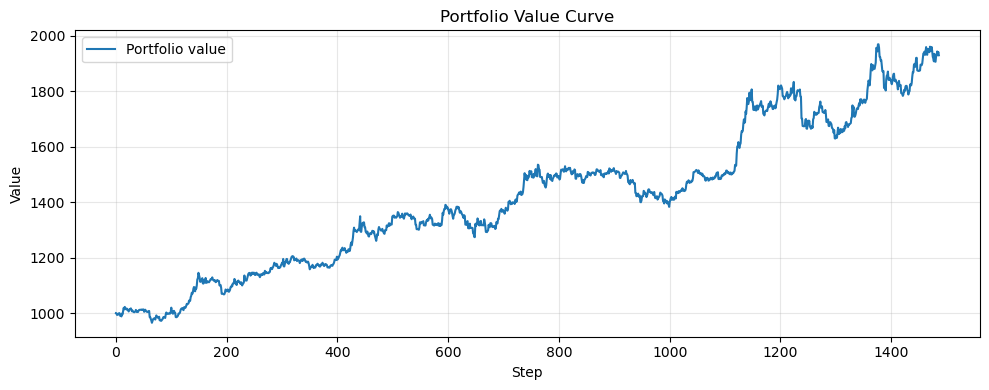

In [37]:
plt.figure(figsize=(10, 4))
plt.plot(values, label='Portfolio value')
plt.title('Portfolio Value Curve')
plt.xlabel('Step')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
